# RQ1 - Does gender predict code comprehension accuracy in the EMIP dataset, after controlling for programming expertise, programming-language expertise, English proficiency, task type, and presentation order?

**The EMIP study follows a mixed factorial design with gender as a between-subjects factor and task (Rectangle vs. Vehicle) as a within-subjects factor. Each participant completed both comprehension tasks, resulting in repeated measures. Task order was counterbalanced across participants as shown in GEE section.**

# Mount and import

In [1]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


In [2]:
import sys
sys.path.append('/content/drive/MyDrive/EMIP-Toolkit')
sys.path.append('/content/drive/MyDrive/EMIP-Toolkit/emtk')
sys.path.append('/content/drive/MyDrive/EMIP-Toolkit/emtk/parsers')

In [3]:
import parsers
import aoi
import visualization
import util

In [4]:
import os
import pandas as pd
import numpy as np

#Load metadata


Load gender map





In [5]:
desired_path = os.path.join(
    '/content/drive/MyDrive/EMIP-Toolkit/emtk/datasets/EMIP',
    'EMIP-Toolkit- replication package',
    'emip_dataset'
)

os.chdir(desired_path)

In [6]:
from collections import Counter
METADATA_FILE = 'emip_metadata.csv'
try:
    metadata_df = pd.read_csv(METADATA_FILE)
    print(f"Loaded metadata for {len(metadata_df)} participants")

except FileNotFoundError:
    print(f"Warning: Metadata file '{METADATA_FILE}' not found")
except Exception as e:
    print(f"Error loading metadata: {e}.")

Loaded metadata for 216 participants


In [7]:
metadata_df.head()

,id,age,gender,mother_tongue,english_level,visual_aid,makeup,experiment_language,expertise_experiment_language,time_experiment_language,...,order_rectangle,stimulus_rectangle,answer_vehicle,correct_vehicle,order_vehicle,stimulus_vehicle,mother_tongue_original,time_experiment_language_original,time_programming_original,other_languages_original
0,1,63,male,Czech,high,glasses,no,Java,high,30.0,...,2,rectangle_java.jpg,"... defines a vehicle by a producer, that has ...",0,1,vehicle_java.jpg,czech,30y,40+,CoffeeScript (high) JavaScript (high) Python (...
1,2,24,male,Slovak,medium,glasses,no,Java,medium,2.0,...,1,rectangle_java2.jpg,"... defines a vehicle by a producer, that has ...",0,2,vehicle_java2.jpg,Slovak,2,5,"c++(low), php(medium), delphi(low)"
2,3,27,female,Hebrew,high,no,no,Java,none,0.0,...,2,rectangle_java2.jpg,"... defines a vehicle by a producer, that has ...",0,1,vehicle_java2.jpg,Hebrew,0,0,c# (low)
3,4,24,male,Hindi,high,glasses,no,Java,medium,4.0,...,1,rectangle_java2.jpg,"... defines a vehicle by a producer, that has ...",0,2,vehicle_java2.jpg,Hindi,4,10,Python(High) C++(High) C(High) HTML/PHP/SQL (H...
4,5,24,male,Italian,medium,no,no,Java,none,0.0,...,1,rectangle_java2.jpg,"... defines a vehicle by a producer, that has ...",0,2,vehicle_java2.jpg,italiano,0,5,"objective C , C"


# Expertise versus gender


In [8]:
metadata_df['time_programming'] = pd.to_numeric(metadata_df['time_programming'], errors='coerce')
metadata_df['time_programming'] = metadata_df['time_programming'].fillna(40.0)

In [9]:
#find all lines in metadata_df where expertise_experiment_language and expertise_programming are dififerent
metadata_df[metadata_df['expertise_experiment_language'] != metadata_df['expertise_programming']]

,id,age,gender,mother_tongue,english_level,visual_aid,makeup,experiment_language,expertise_experiment_language,time_experiment_language,...,order_rectangle,stimulus_rectangle,answer_vehicle,correct_vehicle,order_vehicle,stimulus_vehicle,mother_tongue_original,time_experiment_language_original,time_programming_original,other_languages_original
4,5,24,male,Italian,medium,no,no,Java,none,0.0,...,1,rectangle_java2.jpg,"... defines a vehicle by a producer, that has ...",0,2,vehicle_java2.jpg,italiano,0,5,"objective C , C"
7,8,26,female,Italian,high,no,yes,Java,none,0.0,...,2,rectangle_java2.jpg,"... defines a vehicle by a producer, that has ...",0,1,vehicle_java2.jpg,Italian,0,1,C++ (low)
8,9,38,male,German,high,no,no,Java,low,14.0,...,1,rectangle_java2.jpg,".... defines a vehicle by a producer, that has...",1,2,vehicle_java2.jpg,german,14,14,c++ high python low bash high haskell low asse...
9,10,32,male,Portuguese,high,no,no,Java,low,0.0,...,1,rectangle_java.jpg,"... defines a vehicle by a producer, that has ...",0,2,vehicle_java.jpg,Portuguese,2 months,5 years,"C(high), C++(high), VB(medium), Pascal (medium..."
10,11,34,male,English,high,glasses,no,Java,medium,5.0,...,2,rectangle_java.jpg,"... defines a vehicle by a producer, that has ...",0,1,vehicle_java.jpg,English,5,16,PHP (high) Python (low) Ruby (low) Assembly (l...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
205,206,30,male,English; Hebrew,high,no,no,Java,medium,1.0,...,2,rectangle_java2.jpg,"... defines a vehicle by a producer, that has ...",0,1,vehicle_java2.jpg,english & heb,1,1,java Script (low)
208,209,78,female,English,high,contact lenses,no,Java,medium,5.0,...,2,rectangle_java.jpg,"... defines a vehicle by a producer, that has ...",0,1,vehicle_java.jpg,English,5,56,"Algol (medium), PL1(high),Fortran (high), C (h..."
209,210,31,male,Slovak,high,no,no,Java,medium,0.0,...,2,rectangle_java2.jpg,"... defines a vehicle by a producer, that has ...",0,1,vehicle_java2.jpg,Slovak,0,18,C (high) C# (high)
210,211,21,female,Italian; English,high,no,yes,Java,none,0.0,...,1,rectangle_java2.jpg,"... defines a vehicle by a producer, that has ...",0,2,vehicle_java2.jpg,"Italian, English",0,1,"C, medium"


In [10]:
expertise_counts_p = metadata_df.groupby(['gender', 'expertise_programming']).size().reset_index(name='count')
print("Expertise counts by programming language expertise:")
print(expertise_counts_p)

Expertise counts by programming language expertise:
   gender expertise_programming  count
0  female                  high      4
1  female                   low     13
2  female                medium     18
3  female                  none      6
4    male                  high     36
5    male                   low     32
6    male                medium    102
7    male                  none      5


In [11]:
expertise_counts = metadata_df.groupby(['gender', 'expertise_experiment_language']).size().reset_index(name='count')
print("Expertise counts by gender and experimental language expertise:")
print(expertise_counts)

Expertise counts by gender and experimental language expertise:
   gender expertise_experiment_language  count
0  female                          high      2
1  female                           low     11
2  female                        medium     14
3  female                          none     14
4    male                          high     15
5    male                           low     58
6    male                        medium     86
7    male                          none     16


In [12]:
expertise_percentages = metadata_df.groupby('gender')['expertise_experiment_language'].value_counts(normalize=True).mul(100).unstack(fill_value=0)
print("Expertise percentages by gender and experimental language expertise:")
print(expertise_percentages)

Expertise percentages by gender and experimental language expertise:
expertise_experiment_language      high        low     medium       none
gender                                                                  
female                         4.878049  26.829268  34.146341  34.146341
male                           8.571429  33.142857  49.142857   9.142857


# Metrics of correctness by gender

**Correct answer for rectangle**

In [13]:
metadata_df["correct_rectangle"].value_counts()

,count
correct_rectangle,
1,152
0,64


In [14]:
metadata_df.groupby("gender")["correct_rectangle"].value_counts()

gender  correct_rectangle
female  1                     29
        0                     12
male    1                    123
        0                     52
Name: count, dtype: int64

**Percentage of correct answers by gender - Rectangle**

In [15]:
# Calculate the percentage of correct answers for the 'correct_vehicle' column by gender
gender_rec_correct_percentage = metadata_df.groupby('gender')['correct_rectangle'].value_counts(normalize=True).mul(100).unstack()

display("Percentage of correct rectangle answers by gender:")
display(gender_rec_correct_percentage)

'Percentage of correct rectangle answers by gender:'

correct_rectangle,0,1
gender,,
female,29.268293,70.731707
male,29.714286,70.285714


**Correct answer for Vehicle**

In [16]:
metadata_df["correct_vehicle"].value_counts()

,count
correct_vehicle,
0,166
1,50


In [17]:
metadata_df.groupby("gender")["correct_vehicle"].value_counts()



gender  correct_vehicle
female  0                   35
        1                    6
male    0                  131
        1                   44
Name: count, dtype: int64

**Percentage of correct answers by gender - Vehicle**

In [18]:
# Calculate the percentage of correct answers for the 'correct_vehicle' column by gender
gender_vehicle_correct_percentage = metadata_df.groupby('gender')['correct_vehicle'].value_counts(normalize=True).mul(100).unstack()

print("Percentage of correct vehicle answers by gender:")
display(gender_vehicle_correct_percentage)

Percentage of correct vehicle answers by gender:


correct_vehicle,0,1
gender,,
female,85.365854,14.634146
male,74.857143,25.142857


# Correct answers distribution


The binary outcomes of the code comprehension questions, both rectangle and vehicle have been collapsed into a total score in this section, with 0 indicating the participant got no answer correct, 1 indicating the participant got one answer correct and 2 indicating the participant got both answers correct.


In [19]:
participant_data = metadata_df[['id', 'gender', 'expertise_programming', 'expertise_experiment_language', 'time_programming']].copy()
participant_data['total_score'] = metadata_df['correct_rectangle'] + metadata_df['correct_vehicle']

display(participant_data)


,id,gender,expertise_programming,expertise_experiment_language,time_programming,total_score
0,1,male,high,high,40.0,1
1,2,male,medium,medium,5.0,0
2,3,female,none,none,0.0,1
3,4,male,medium,medium,10.0,1
4,5,male,low,none,5.0,1
...,...,...,...,...,...,...
211,212,male,medium,medium,3.0,1
212,213,male,medium,low,3.0,0
213,214,male,medium,medium,4.0,2
214,215,male,medium,medium,2.0,1


In [20]:
#find all rows where time_programming has NAN and add 40.0 in its place
participant_data['time_programming'] = pd.to_numeric(participant_data['time_programming'], errors='coerce')
participant_data['time_programming'] = participant_data['time_programming'].fillna(40.0)
#add another column to participant_data named 'is_experienced' which should be 1 if time_programming is greater r equal to 2 else it should be 0
participant_data['is_experienced'] = np.where(participant_data['time_programming'] >= 4, 1, 0)
display(participant_data)

,id,gender,expertise_programming,expertise_experiment_language,time_programming,total_score,is_experienced
0,1,male,high,high,40.0,1,1
1,2,male,medium,medium,5.0,0,1
2,3,female,none,none,0.0,1,0
3,4,male,medium,medium,10.0,1,1
4,5,male,low,none,5.0,1,1
...,...,...,...,...,...,...,...
211,212,male,medium,medium,3.0,1,0
212,213,male,medium,low,3.0,0,0
213,214,male,medium,medium,4.0,2,1
214,215,male,medium,medium,2.0,1,0


In [21]:
#from participant_data find the females who have a total score of 2
female_correct_both = participant_data[(participant_data['gender'] == 'female') & (participant_data['total_score'] == 2)]
display(female_correct_both)

,id,gender,expertise_programming,expertise_experiment_language,time_programming,total_score,is_experienced
18,19,female,medium,medium,3.0,2,0
94,95,female,medium,none,5.0,2,1
149,150,female,medium,medium,10.0,2,1
179,180,female,low,low,2.0,2,0


In [22]:

female_correct_none = participant_data[(participant_data['gender'] == 'female') & (participant_data['total_score'] == 0)]
display(female_correct_none)

,id,gender,expertise_programming,expertise_experiment_language,time_programming,total_score,is_experienced
11,12,female,low,none,4.0,0,1
35,36,female,none,none,0.0,0,0
64,65,female,low,low,1.0,0,0
75,76,female,high,high,4.0,0,1
92,93,female,none,none,0.0,0,0
102,103,female,low,low,1.0,0,0
106,107,female,medium,low,3.0,0,0
147,148,female,high,medium,2.0,0,0
180,181,female,none,none,0.0,0,0
203,204,female,low,none,0.5,0,0


In [23]:
# Calculate percentages of total scores by gender
score_percentages = participant_data.groupby('gender')['total_score'].value_counts(normalize=True).mul(100).rename('percentage').reset_index()
display(score_percentages)


,gender,total_score,percentage
0,female,1,65.853659
1,female,0,24.390244
2,female,2,9.756098
3,male,1,60.000000
4,male,0,22.285714
5,male,2,17.714286


In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


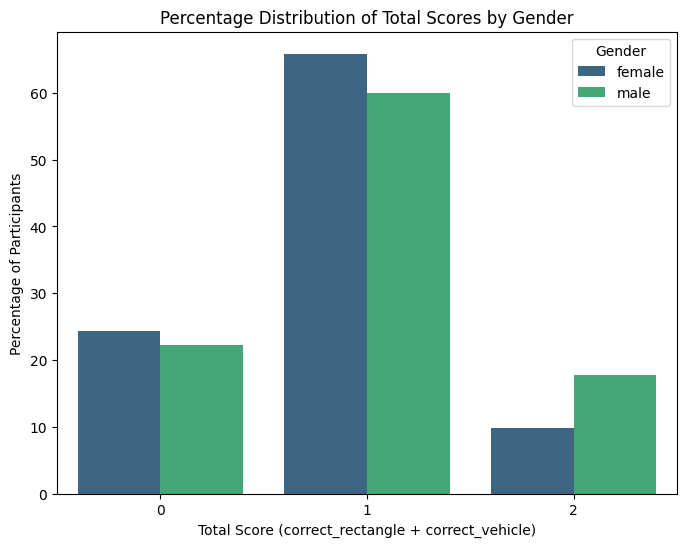

In [25]:
plt.figure(figsize=(8, 6))
sns.barplot(x='total_score', y='percentage', hue='gender', data=score_percentages, palette='viridis')
plt.title('Percentage Distribution of Total Scores by Gender')
plt.xlabel('Total Score (correct_rectangle + correct_vehicle)')
plt.ylabel('Percentage of Participants')
plt.xticks(ticks=[0, 1, 2], labels=['0', '1', '2'])
plt.legend(title='Gender')
plt.show()

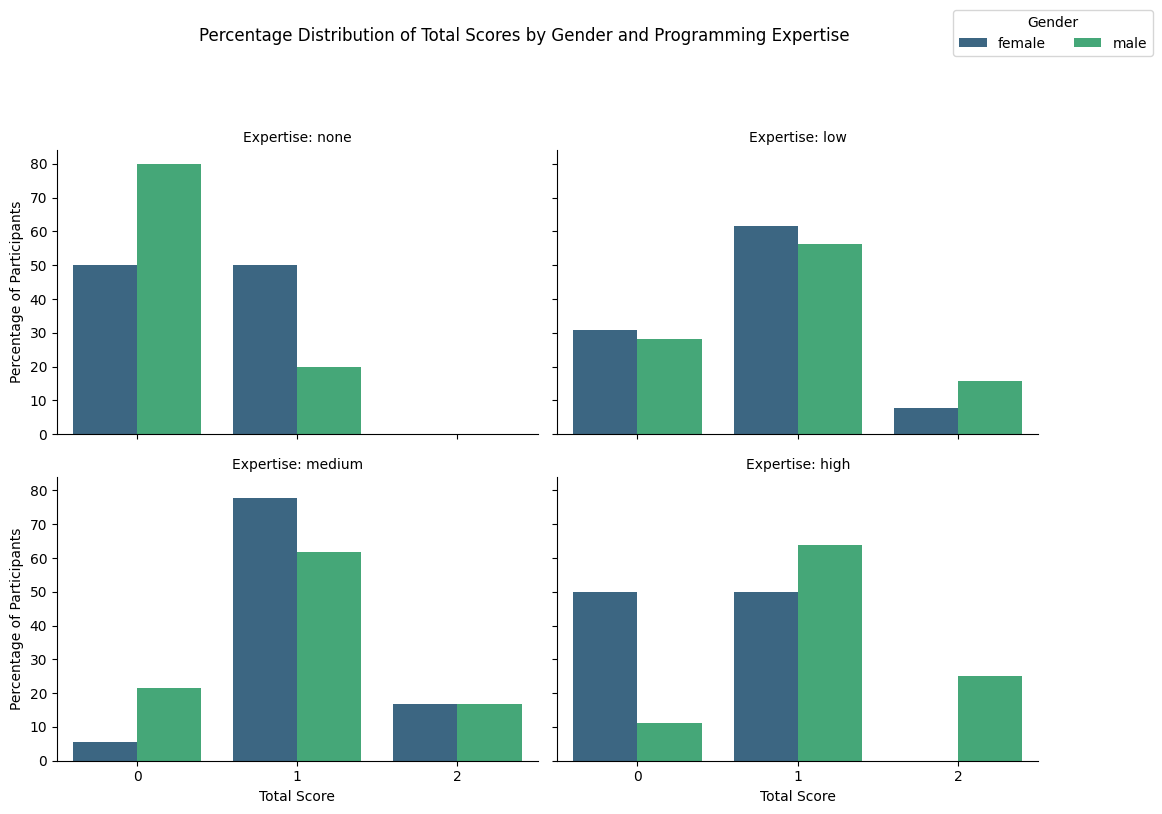

In [26]:
# Ensure expertise_programming has a defined order for better visualization
expertise_order = ['none', 'low', 'medium', 'high']
participant_data['expertise_programming'] = pd.Categorical(participant_data['expertise_programming'], categories=expertise_order, ordered=True)

# Calculate percentages of total scores by gender and expertise_programming
# Use observed=False to suppress FutureWarning about categorical columns if desired
detailed_score_percentages = participant_data.groupby(['gender', 'expertise_programming', 'total_score'], observed=False).size().reset_index(name='count')

# Corrected line using .transform() to get percentages that align with the original DataFrame's index
detailed_score_percentages['percentage'] = detailed_score_percentages.groupby(['gender', 'expertise_programming'], observed=False)['count'].transform(lambda x: 100 * x / x.sum())

# The following line is redundant as detailed_score_percentages already has a flat index
# detailed_score_percentages = detailed_score_percentages.reset_index()

# Create the bar plot using catplot for faceting
g = sns.catplot(
    data=detailed_score_percentages,
    x='total_score',
    y='percentage',
    hue='gender',
    col='expertise_programming',
    col_wrap=2, # Wrap columns after 2 plots
    kind='bar',
    palette='viridis',
    height=4, aspect=1.2,
    col_order=expertise_order # Ensure order of expertise is maintained for 'col' facet
)

g.set_axis_labels('Total Score', 'Percentage of Participants')
g.set_titles('Expertise: {col_name}')
g.fig.suptitle('Percentage Distribution of Total Scores by Gender and Programming Expertise', y=1.02) # Adjust suptitle position
plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent suptitle overlap
# Move legend
g._legend.remove()  # Remove the default legend
g.fig.legend(loc='upper center', bbox_to_anchor=(1, 1.05), ncol=2, title='Gender')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Adjust to make room at top
plt.show()

In [27]:
 #display(detailed_score_percentages)

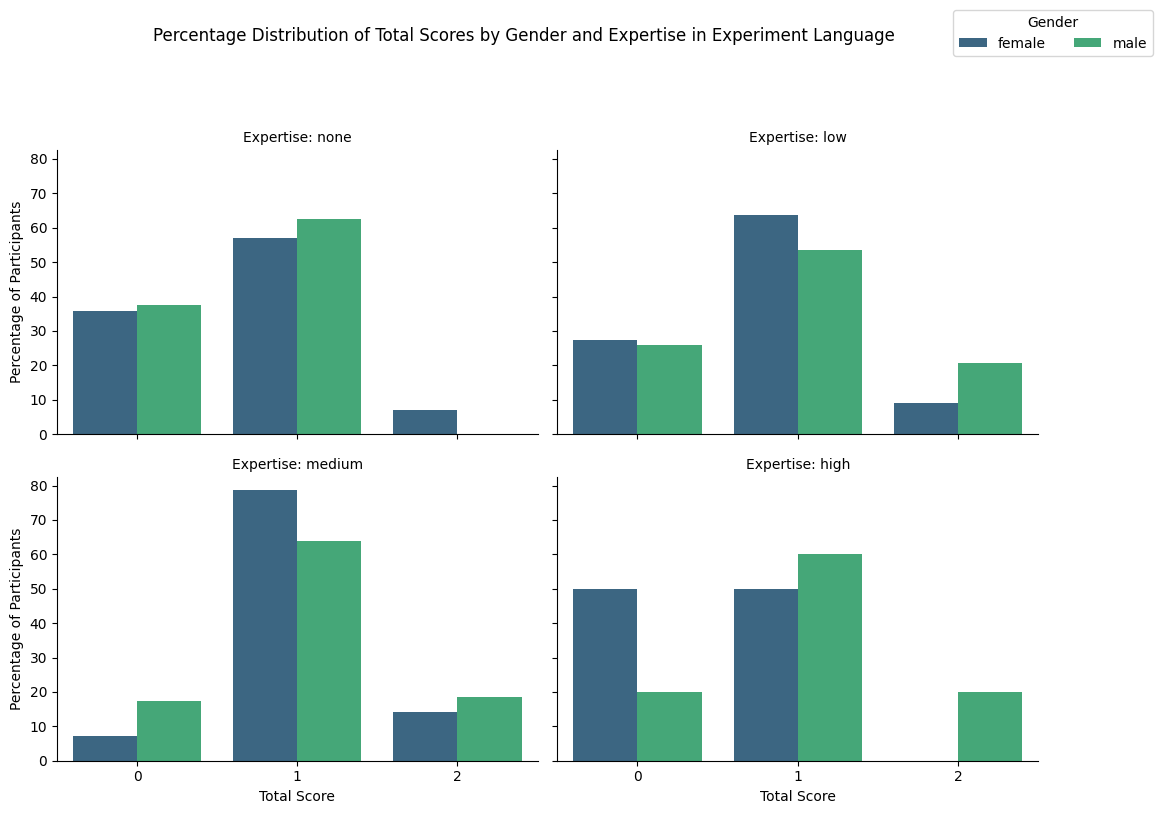

In [28]:
expertise_order = ['none', 'low', 'medium', 'high']
participant_data['expertise_experiment_language'] = pd.Categorical(participant_data['expertise_experiment_language'], categories=expertise_order, ordered=True)

# Calculate percentages of total scores by gender and expertise_programming
# Use observed=False to suppress FutureWarning about categorical columns if desired
detailed_score_percentages = participant_data.groupby(['gender', 'expertise_experiment_language', 'total_score'], observed=False).size().reset_index(name='count')

# Corrected line using .transform() to get percentages that align with the original DataFrame's index
detailed_score_percentages['percentage'] = detailed_score_percentages.groupby(['gender', 'expertise_experiment_language'], observed=False)['count'].transform(lambda x: 100 * x / x.sum())

# The following line is redundant as detailed_score_percentages already has a flat index
# detailed_score_percentages = detailed_score_percentages.reset_index()

# Create the bar plot using catplot for faceting
g = sns.catplot(
    data=detailed_score_percentages,
    x='total_score',
    y='percentage',
    hue='gender',
    col='expertise_experiment_language',
    col_wrap=2, # Wrap columns after 2 plots
    kind='bar',
    palette='viridis',
    height=4, aspect=1.2,
    col_order=expertise_order # Ensure order of expertise is maintained for 'col' facet
)

g.set_axis_labels('Total Score', 'Percentage of Participants')
g.set_titles('Expertise: {col_name}')
g.fig.suptitle('Percentage Distribution of Total Scores by Gender and Expertise in Experiment Language', y=1.02) # Adjust suptitle position
plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent suptitle overlap
# Move legend
g._legend.remove()  # Remove the default legend
g.fig.legend(loc='upper center', bbox_to_anchor=(1, 1.05), ncol=2, title='Gender')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Adjust to make room at top
plt.show()

In [29]:
display(detailed_score_percentages)

,gender,expertise_experiment_language,total_score,count,percentage
0,female,none,0,5,35.714286
1,female,none,1,8,57.142857
2,female,none,2,1,7.142857
3,female,low,0,3,27.272727
4,female,low,1,7,63.636364
5,female,low,2,1,9.090909
6,female,medium,0,1,7.142857
7,female,medium,1,11,78.571429
8,female,medium,2,2,14.285714
9,female,high,0,1,50.000000


In [30]:
# Ensure is_experienced is treated as a categorical variable for better visualization
participant_data['is_experienced'] = participant_data['is_experienced'].astype('category')

# Calculate percentages of total scores by gender and is_experienced
detailed_score_percentages_exp = participant_data.groupby(['gender', 'is_experienced', 'total_score'], observed=False).size().reset_index(name='count')
detailed_score_percentages_exp['percentage'] = detailed_score_percentages_exp.groupby(['gender', 'is_experienced'], observed=False)['count'].transform(lambda x: 100 * x / x.sum())
display(detailed_score_percentages_exp)

,gender,is_experienced,total_score,count,percentage
0,female,0,0,8,30.769231
1,female,0,1,16,61.538462
2,female,0,2,2,7.692308
3,female,1,0,2,13.333333
4,female,1,1,11,73.333333
5,female,1,2,2,13.333333
6,male,0,0,23,27.710843
7,male,0,1,48,57.831325
8,male,0,2,12,14.457831
9,male,1,0,16,17.391304


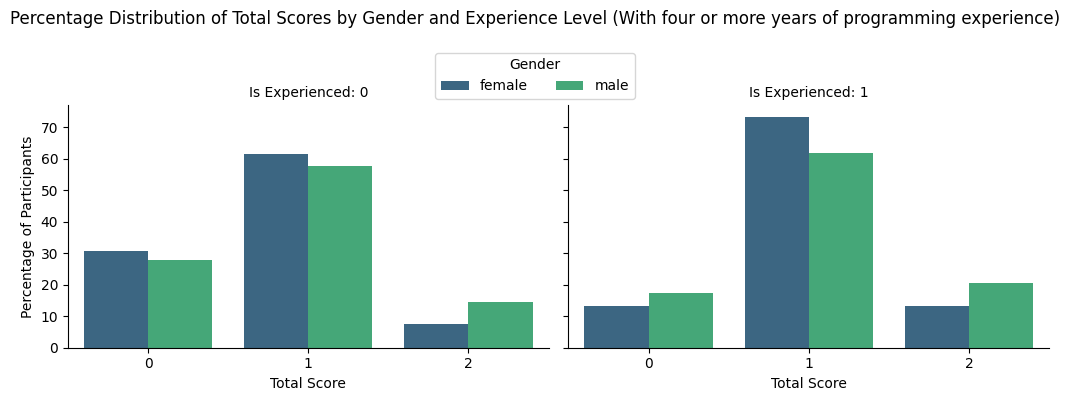

In [31]:


# Create the bar plot using catplot for faceting by is_experienced
g = sns.catplot(
    data=detailed_score_percentages_exp,
    x='total_score',
    y='percentage',
    hue='gender',
    col='is_experienced',
    kind='bar',
    palette='viridis',
    height=4, aspect=1.2
)

g.set_axis_labels('Total Score', 'Percentage of Participants')
g.set_titles('Is Experienced: {col_name}')
g.fig.suptitle('Percentage Distribution of Total Scores by Gender and Experience Level (With four or more years of programming experience)', y=1.02) # Adjust suptitle position
plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent suptitle overlap

# Move legend
g._legend.remove()  # Remove the default legend
g.fig.legend(loc='upper center', bbox_to_anchor=(0.5, 0.93), ncol=2, title='Gender')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Adjust to make room at top
plt.show()

# Chi-square test

“A chi-square test of independence was conducted to examine the association between gender and comprehension accuracy. While this provided an initial overview, it did not account for confounding variables such as programming expertise or task difficulty. It also assumes that all observations are independent. In the EMIP dataset, each participant answers two comprehension questions (Rectangle and Vehicle), meaning the responses are repeated measures from the same individual. Treating these as independent violates a core assumption of the chi‑square test and can lead to inaccurate p‑values. Therefore, chi‑square results are used only for exploratory purposes, and a logistic regression model is employed to assess the adjusted relationship between gender and comprehension performance.”

In [32]:
from scipy.stats import chi2_contingency

In [33]:
# Chi-square test for correct_rectangle and gender
contingency_table_rectangle = pd.crosstab(metadata_df['gender'], metadata_df['correct_rectangle'])
print (contingency_table_rectangle)
chi2_stat_rectangle, p_value_rectangle, dof_rectangle, expected_rectangle = chi2_contingency(contingency_table_rectangle)

print("Chi-square test for Correct Rectangle and Gender:")
print(f"Chi-square statistic: {chi2_stat_rectangle:.4f}")
print(f"P-value: {p_value_rectangle:.4f}")
print(f"Degrees of freedom: {dof_rectangle}")
print("Expected frequencies:")
print(expected_rectangle)

# Interpretation for rectangle
alpha = 0.05
if p_value_rectangle < alpha:
    print("\nResult for Correct Rectangle: Reject the null hypothesis. There is a statistically significant relationship between gender and correct rectangle answers.")
else:
    print("\nResult for Correct Rectangle: Fail to reject the null hypothesis. There is no statistically significant relationship between gender and correct rectangle answers.")

correct_rectangle   0    1
gender                    
female             12   29
male               52  123
Chi-square test for Correct Rectangle and Gender:
Chi-square statistic: 0.0000
P-value: 1.0000
Degrees of freedom: 1
Expected frequencies:
[[ 12.14814815  28.85185185]
 [ 51.85185185 123.14814815]]

Result for Correct Rectangle: Fail to reject the null hypothesis. There is no statistically significant relationship between gender and correct rectangle answers.


In [34]:

# Chi-square test for correct_vehicle and gender
contingency_table_vehicle = pd.crosstab(metadata_df['gender'], metadata_df['correct_vehicle'])
chi2_stat_vehicle, p_value_vehicle, dof_vehicle, expected_vehicle = chi2_contingency(contingency_table_vehicle)
print (contingency_table_vehicle)
print("Chi-square test for Correct Vehicle and Gender:")
print(f"Chi-square statistic: {chi2_stat_vehicle:.4f}")
print(f"P-value: {p_value_vehicle:.4f}")
print(f"Degrees of freedom: {dof_vehicle}")
print("Expected frequencies:")
print(expected_vehicle)

# Interpretation for vehicle
alpha = 0.05
if p_value_vehicle < alpha:
    print("\nResult for Correct Vehicle: Reject the null hypothesis. There is a statistically significant relationship between gender and correct vehicle answers.")
else:
    print("\nResult for Correct Vehicle: Fail to reject the null hypothesis. There is no statistically significant relationship between gender and correct vehicle answers.")


correct_vehicle    0   1
gender                  
female            35   6
male             131  44
Chi-square test for Correct Vehicle and Gender:
Chi-square statistic: 1.5136
P-value: 0.2186
Degrees of freedom: 1
Expected frequencies:
[[ 31.50925926   9.49074074]
 [134.49074074  40.50925926]]

Result for Correct Vehicle: Fail to reject the null hypothesis. There is no statistically significant relationship between gender and correct vehicle answers.


Initial chi‑square tests showed no significant association between gender and correctness. However, these tests do not account for expertise or repeated measures.

Why the Chi-Square Test is Inappropriate

A standard Chi-square (or Fisher’s exact) test is unsuitable for this dataset because it fundamentally assumes independence of observations.
Each participant provided two responses (one for the easy question - Rectangle, one for the difficult question - Vehicle). This creates a "repeated measures" or "clustered" data structure where the two answers from the same person are likely correlated (e.g., a highly experienced expert is likely to get both correct).
Applying a Chi-square test here would be incorrect for two main reasons:

Violation of Independence: It would treat the total responses as if they came from 432 different people, ignoring the internal correlation within subjects. This artificially inflates the sample size and leads to invalid $p$-values and Type I errors.
Inability to Adjust for Covariates: A simple Chi-square test looks only at the relationship between two variables (e.g., Gender vs. Correctness). It cannot simultaneously account for the difficulty of the question, the participant's self-reported expertise, or their years of experience

# **GEE**

In [35]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.genmod.generalized_estimating_equations import GEE
from statsmodels.genmod.families import Binomial
from statsmodels.genmod.cov_struct import Exchangeable
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor


In [36]:

def infer_order(row):
    if pd.notna(row.get('order_vehicle')) and row['order_vehicle'] == 1:
        return 'vehicle_first'
    if pd.notna(row.get('order_rectangle')) and row['order_rectangle'] == 1:
        return 'rectangle_first'
    return np.nan

metadata_df['order'] = metadata_df.apply(infer_order, axis=1)


In [37]:
metadata_df['order'] = metadata_df['order'].astype('category')
metadata_df['order_bin'] = (metadata_df['order'] == 'vehicle_first').astype(int)

# Check balance by gender and other covariates
print(pd.crosstab(metadata_df['order'], metadata_df['gender']))
print(metadata_df['order'].value_counts(dropna=False))


gender           female  male
order                        
rectangle_first      20    85
vehicle_first        21    90
order
vehicle_first      111
rectangle_first    105
Name: count, dtype: int64


In [38]:
display(metadata_df)

,id,age,gender,mother_tongue,english_level,visual_aid,makeup,experiment_language,expertise_experiment_language,time_experiment_language,...,answer_vehicle,correct_vehicle,order_vehicle,stimulus_vehicle,mother_tongue_original,time_experiment_language_original,time_programming_original,other_languages_original,order,order_bin
0,1,63,male,Czech,high,glasses,no,Java,high,30.0,...,"... defines a vehicle by a producer, that has ...",0,1,vehicle_java.jpg,czech,30y,40+,CoffeeScript (high) JavaScript (high) Python (...,vehicle_first,1
1,2,24,male,Slovak,medium,glasses,no,Java,medium,2.0,...,"... defines a vehicle by a producer, that has ...",0,2,vehicle_java2.jpg,Slovak,2,5,"c++(low), php(medium), delphi(low)",rectangle_first,0
2,3,27,female,Hebrew,high,no,no,Java,none,0.0,...,"... defines a vehicle by a producer, that has ...",0,1,vehicle_java2.jpg,Hebrew,0,0,c# (low),vehicle_first,1
3,4,24,male,Hindi,high,glasses,no,Java,medium,4.0,...,"... defines a vehicle by a producer, that has ...",0,2,vehicle_java2.jpg,Hindi,4,10,Python(High) C++(High) C(High) HTML/PHP/SQL (H...,rectangle_first,0
4,5,24,male,Italian,medium,no,no,Java,none,0.0,...,"... defines a vehicle by a producer, that has ...",0,2,vehicle_java2.jpg,italiano,0,5,"objective C , C",rectangle_first,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211,212,21,male,Slovak,high,glasses,no,Java,medium,2.0,...,".... defines a vehicle by a producer, that has...",1,2,vehicle_java2.jpg,slovak,2,3,"C (high), C++ (low)",rectangle_first,0
212,213,26,male,Hindi,high,no,no,Java,low,0.5,...,I'm not sure.,0,2,vehicle_java2.jpg,Hindi,6 months,3 years,Python(medium) VBA(High) Excel(High) C(medium),rectangle_first,0
213,214,21,male,Slovak,high,no,no,Java,medium,1.0,...,".... defines a vehicle by a producer, that has...",1,2,vehicle_java2.jpg,Slovak,1,4,"C (medium) , JavaScript (medium)",rectangle_first,0
214,215,22,male,Slovak,medium,no,no,Java,medium,1.0,...,".... defines a vehicle by a producer, that has...",1,1,vehicle_java2.jpg,slovak,1,2,C (medium) c# (medium) Java (medium),vehicle_first,1


**Task presentation order was counterbalanced across participants, with 105 participants viewing Rectangle first and 111 viewing Vehicle first. The proportion of female participants was nearly identical across order conditions (20 vs 21), indicating that order was not confounded with gender.**

In [39]:
# Reshape to long format: one row per participant-task
long = pd.melt(
    metadata_df,
    id_vars=['id','gender','order','expertise_programming','expertise_experiment_language','time_programming','english_level'],
    value_vars=['correct_rectangle','correct_vehicle'],
    var_name='task',
    value_name='correct'
)

# Clean task names and set rectangle as baseline
long['task'] = long['task'].str.replace('correct_','')
long['task'] = pd.Categorical(long['task'], categories=['rectangle','vehicle'])

# Binary outcome
long['correct'] = long['correct'].astype(int)

# Encode gender: female = 1, male = 0
long['gender_bin'] = (long['gender'] == 'female').astype(int)

# Map expertise_programming (example mapping; adjust if your labels differ)
exp_map = {'none':0, 'low':1, 'medium':2, 'high':3}
long['expertise_programming_num'] = long['expertise_programming'].map(exp_map)

# Map expertise_experiment_language
long['expertise_experiment_num'] = long['expertise_experiment_language'].map(exp_map)

# Map English_level High = 1, Medium - 0 - no participants exist with low level of English language
long['english_bin'] = (long['english_level'] == 'high').astype(int)

#long['order_bin'] = (long['order'] == 'vehicle_first').astype(int)

# Ensure time_programming is numeric in the long format for VIF calculation
#long['time_programming'] = pd.to_numeric(long['time_programming'], errors='coerce')

# Drop rows with missing key variables - no need to do this, no rows with missing variables
#long = long.dropna(subset=['correct','gender_bin','expertise_programming_num','expertise_experiment_num','english_bin','task','id'])

#print("Number of rows in long:", len(long))

# Quick descriptive checks
#print("\nCounts by task and gender:\n", long.groupby(['task','gender'], observed=False).agg(n=('id','count'), accuracy=('correct','mean')).reset_index())
#print("\nOrder balance by gender:\n", pd.crosstab(long.drop_duplicates('id')['order'], long.drop_duplicates('id')['gender']))


Task order was modeled as a trial‑level variable indicating whether the specific task was presented first or second. This approach captures learning or fatigue effects. A participant‑level order variable (e.g., vehicle‑first vs rectangle‑first group) would not correctly represent the order in which each task was encountered, so a trial‑level coding was used instead.

In [40]:
def task_order(row):
    if row['order'] == 'vehicle_first' and row['task'] == 'vehicle':
        return 1
    if row['order'] == 'vehicle_first' and row['task'] == 'rectangle':
        return 2
    if row['order'] == 'rectangle_first' and row['task'] == 'rectangle':
        return 1
    if row['order'] == 'rectangle_first' and row['task'] == 'vehicle':
        return 2
    return np.nan

long['task_order'] = long.apply(task_order, axis=1)
long['task_order'] = long['task_order'].astype(int)


In [41]:
#display long sorted by id
display(long.sort_values(by='id'))

,id,gender,order,expertise_programming,expertise_experiment_language,time_programming,english_level,task,correct,gender_bin,expertise_programming_num,expertise_experiment_num,english_bin,task_order
216,1,male,vehicle_first,high,high,40.0,high,vehicle,0,0,3,3,1,1
0,1,male,vehicle_first,high,high,40.0,high,rectangle,1,0,3,3,1,2
1,2,male,rectangle_first,medium,medium,5.0,medium,rectangle,0,0,2,2,0,1
217,2,male,rectangle_first,medium,medium,5.0,medium,vehicle,0,0,2,2,0,2
218,3,female,vehicle_first,none,none,0.0,high,vehicle,0,1,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
429,214,male,rectangle_first,medium,medium,4.0,high,vehicle,1,0,2,2,1,2
214,215,male,vehicle_first,medium,medium,2.0,medium,rectangle,0,0,2,2,0,2
430,215,male,vehicle_first,medium,medium,2.0,medium,vehicle,1,0,2,2,0,1
431,216,female,vehicle_first,none,none,0.0,high,vehicle,0,1,0,0,1,1


In [42]:
#how many participants with english_bin as 1 and how many 0 - two lines for each participant, so divide by 2
long['english_bin'].value_counts()/2

,count
english_bin,
1,123.0
0,93.0


In [43]:
#long[long['time_programming'] >= 40]

In [44]:
#long['time_programming'].describe()


In [45]:

# Prepare numeric predictors for VIF, dropping any remaining NaNs if present after explicit conversion

vif_df = long[['id','expertise_programming_num','expertise_experiment_num','english_bin','time_programming']].drop_duplicates('id').drop(columns='id') #there are two rows per participant- only one needed
vif_df = vif_df[['expertise_programming_num','expertise_experiment_num','english_bin','time_programming']].dropna()

# Add constant for VIF calculation
X = sm.add_constant(vif_df)

vifs = pd.Series(
    [variance_inflation_factor(X.values, i+1) for i in range(X.shape[1]-1)],  # skip const
    index=['expertise_programming_num','expertise_experiment_num','english_bin','time_programming']
)
print("\nVIFs:\n", vifs)

# Correlation matrix
print("\nCorrelation matrix:\n")
display(vif_df.corr())


VIFs:
 expertise_programming_num    2.172509
expertise_experiment_num     1.780160
english_bin                  1.002032
time_programming             1.342864
dtype: float64

Correlation matrix:



,expertise_programming_num,expertise_experiment_num,english_bin,time_programming
expertise_programming_num,1.000000,0.660210,0.029118,0.502780
expertise_experiment_num,0.660210,1.000000,0.042682,0.295277
english_bin,0.029118,0.042682,1.000000,0.025466
time_programming,0.502780,0.295277,0.025466,1.000000


Before running the regression model, I examined whether any of the predictors were too similar to each other, which can distort model estimates.

Multicollinearity diagnostics were conducted using both the Variance Inflation Factor (VIF) and a Pearson correlation matrix. All predictors showed VIF values well below the commonly accepted threshold of 5 (expertise in programming: 2.17; expertise in experiment language: 1.78; English proficiency: 1.00; time spent programming: 1.34).

The correlation matrix further supported this conclusion. Although programming expertise was moderately correlated with experiment‑language expertise (r = 0.66) and time spent programming (r = 0.50), these relationships did not reach levels typically considered problematic. All other correlations were weak (r < 0.30).

English proficiency was included as a binary predictor (high vs. medium). The distribution across levels was sufficiently balanced (123 high, 93 medium), and VIF values indicated no multicollinearity (VIF = 1.00). Therefore, English proficiency was retained in the model to control for potential language‑related effects.

In [46]:
# Primary formula: population-average model accounting for repeated measures
formula = "correct ~ gender_bin + expertise_programming_num + expertise_experiment_num + english_bin + C(task) + task_order"

model_gee = GEE.from_formula(formula, groups="id", data=long, family=Binomial(), cov_struct=Exchangeable())
result_gee = model_gee.fit()
print(result_gee.summary())

                               GEE Regression Results                              
Dep. Variable:                     correct   No. Observations:                  432
Model:                                 GEE   No. clusters:                      216
Method:                        Generalized   Min. cluster size:                   2
                      Estimating Equations   Max. cluster size:                   2
Family:                           Binomial   Mean cluster size:                 2.0
Dependence structure:         Exchangeable   Num. iterations:                     5
Date:                     Wed, 11 Feb 2026   Scale:                           1.000
Covariance type:                    robust   Time:                         02:23:25
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept                    -0.3562      0.502     -0.7

We used a population-averaged generalized estimating equation (GEE) logistic model to examine whether gender predicts code comprehension accuracy, while accounting for within-subject correlation across tasks and controlling for expertise, task difficulty, and order effects.

In statsmodels, the baseline category for a categorical variable is the first category in the variable’s defined order. Because the task variable was coded with rectangle as the first category, it served as the reference level in the GEE model.

In [47]:
formula = "correct ~ gender_bin + expertise_programming_num + C(task) + task_order"

model_gee = GEE.from_formula(formula, groups="id", data=long, family=Binomial(), cov_struct=Exchangeable())
result_gee = model_gee.fit()
print(result_gee.summary())

                               GEE Regression Results                              
Dep. Variable:                     correct   No. Observations:                  432
Model:                                 GEE   No. clusters:                      216
Method:                        Generalized   Min. cluster size:                   2
                      Estimating Equations   Max. cluster size:                   2
Family:                           Binomial   Mean cluster size:                 2.0
Dependence structure:         Exchangeable   Num. iterations:                     5
Date:                     Wed, 11 Feb 2026   Scale:                           1.000
Covariance type:                    robust   Time:                         02:23:25
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept                    -0.1791      0.476     -0.3

To evaluate whether additional background variables improved the prediction of code‑comprehension accuracy, two GEE models were compared. The focused model included only the predictors required to answer the research question—gender, programming expertise, task type, and trial‑level task order. The expanded model added two further predictors: experiment‑language expertise and English proficiency.

Experiment‑language expertise reflects how familiar participants were with the specific programming language used in the tasks. This variable was included to test whether task‑specific experience provided explanatory value beyond general programming expertise. However, its coefficient was extremely small and non‑significant (p = .945), indicating that familiarity with the experiment language did not meaningfully influence accuracy once general programming expertise was accounted for.

English proficiency was added to assess whether language ability affected participants’ comprehension of task instructions or code comments. Although the coefficient was positive, suggesting that high‑proficiency participants might perform slightly better, the effect did not reach statistical significance (p = .070). This indicates that English proficiency did not reliably predict accuracy in this context.

Importantly, adding these two predictors did not change the conclusions about the primary variables of interest. In both models, gender remained non‑significant, programming expertise remained a significant positive predictor, and the vehicle task remained substantially more difficult than the rectangle task. Task order also remained non‑significant in both models, suggesting no detectable learning or fatigue effects.

Because the additional predictors did not improve explanatory power, did not alter the interpretation of the main effects, and were not central to the research question, the focused model was retained as the final model. This model provides a more parsimonious and theoretically coherent explanation of the data while still controlling for the key factors relevant to the research question.

In [48]:
params = result_gee.params
conf = result_gee.conf_int()
or_series = np.exp(params)
ci_lower = np.exp(conf[0])
ci_upper = np.exp(conf[1])

summary_or = pd.DataFrame({
    'coef': params,
    'OR': or_series,
    'CI_lower': ci_lower,
    'CI_upper': ci_upper,
    'pvalue': result_gee.pvalues
})

# Round for readability
print("\nPopulation-average Odds Ratios (GEE):\n", summary_or.round(4))


Population-average Odds Ratios (GEE):
                              coef      OR  CI_lower  CI_upper  pvalue
Intercept                 -0.1791  0.8360    0.3286    2.1267  0.7069
C(task)[T.vehicle]        -2.1228  0.1197    0.0763    0.1878  0.0000
gender_bin                -0.0483  0.9528    0.5522    1.6441  0.8622
expertise_programming_num  0.4657  1.5931    1.1727    2.1643  0.0029
task_order                 0.1362  1.1459    0.7391    1.7767  0.5427


A population-average logistic regression model using generalized estimating equations (GEE) was fitted to predict comprehension accuracy while accounting for repeated measures across tasks.

The population‑average odds ratios from the GEE model provide an intuitive interpretation of each predictor’s effect on the likelihood of answering a comprehension question correctly. Task type showed the strongest effect: the odds of a correct response on the vehicle task were only 12% of the odds on the rectangle task (OR = 0.12, 95% CI [0.08, 0.19], p < .001), confirming that the vehicle task was substantially more difficult. Programming expertise was also a significant predictor, with each one‑unit increase in expertise associated with a 59% increase in the odds of answering correctly (OR = 1.59, 95% CI [1.17, 2.16], p = .003). In contrast, gender did not meaningfully influence performance: the odds ratio for females relative to males was close to 1 (OR = 0.95, 95% CI [0.55, 1.64], p = .862), indicating no detectable gender differences in accuracy once expertise and task type were controlled for. Task order likewise showed no significant effect (OR = 1.15, 95% CI [0.74, 1.78], p = .543), suggesting that seeing a task first or second did not influence the likelihood of a correct response.

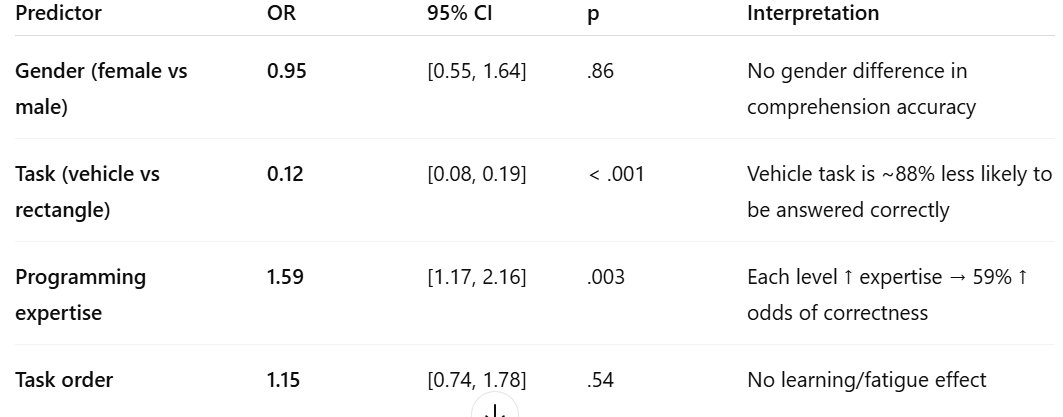

In [49]:
# Interaction model to test whether gender effect differs by task
formula_int = "correct ~ gender_bin * C(task) + expertise_programming_num + task_order"
#formula_int = "correct ~ gender_bin * C(task) + expertise_programming_num + expertise_experiment_num + english_bin + task_order"
model_gee_int = GEE.from_formula(formula_int, groups="id", data=long, family=Binomial(), cov_struct=Exchangeable())
res_int = model_gee_int.fit()
print(res_int.summary())

# Odds ratios for interaction model
params_int = res_int.params
conf_int = res_int.conf_int()
or_int = np.exp(params_int)
ci_lower_int = np.exp(conf_int[0])
ci_upper_int = np.exp(conf_int[1])
pd.DataFrame({'coef':params_int,'OR':or_int,'CI_lower':ci_lower_int,'CI_upper':ci_upper_int,'pvalue':res_int.pvalues}).round(4)

                               GEE Regression Results                              
Dep. Variable:                     correct   No. Observations:                  432
Model:                                 GEE   No. clusters:                      216
Method:                        Generalized   Min. cluster size:                   2
                      Estimating Equations   Max. cluster size:                   2
Family:                           Binomial   Mean cluster size:                 2.0
Dependence structure:         Exchangeable   Num. iterations:                     5
Date:                     Wed, 11 Feb 2026   Scale:                           1.000
Covariance type:                    robust   Time:                         02:23:26
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept                        -0.2525      0.

,coef,OR,CI_lower,CI_upper,pvalue
Intercept,-0.2525,0.7769,0.3013,2.0029,0.6013
C(task)[T.vehicle],-1.9992,0.1354,0.0833,0.2202,0.0000
gender_bin,0.2593,1.2960,0.6018,2.7911,0.5077
gender_bin:C(task)[T.vehicle],-0.7379,0.4781,0.1387,1.6477,0.2424
expertise_programming_num,0.4719,1.6031,1.1755,2.1862,0.0029
task_order,0.1377,1.1476,0.7404,1.7787,0.5380


To examine whether gender differences in comprehension accuracy varied across the two task types, an interaction model including a gender × task term was fitted. The interaction was not significant (OR = 0.48, 95% CI [0.14, 1.65], p = .242), indicating that the effect of gender did not differ between the rectangle and vehicle tasks. Gender remained non‑significant on the baseline task (OR = 1.30, p = .508), and the vehicle task remained substantially more difficult for all participants (OR = 0.14, p < .001). Programming expertise continued to be a strong positive predictor of accuracy, and task order remained non‑significant. Because the interaction did not improve model fit or alter the interpretation of the main predictors, the simpler main‑effects model was retained as the final model.

Although the female subgroup was smaller than the male subgroup (41 vs. 175 participants), the estimated gender effect was close to null, and the confidence interval excluded moderate to large effects. Specifically, the 95% confidence interval for the gender odds ratio ranged from 0.55 to 1.64, indicating that any true effect of gender on comprehension accuracy is unlikely to be large. While very small effects cannot be ruled out, the results suggest that gender differences, if present, are likely to be small and of limited practical significance

Although the gender groups in this study were imbalanced (41 females vs. 175 males), which reduces statistical power to detect very small gender effects, the analysis still had adequate power to detect moderate or large differences. The GEE model successfully identified strong effects of task type and programming expertise, indicating that the dataset was sufficiently sensitive to detect meaningful predictors. The estimated gender effect was extremely small (OR = 0.95) and the confidence interval was wide but centered around 1, providing no indication of even a moderate gender difference. Therefore, while very subtle gender effects cannot be ruled out, the results suggest that any true gender difference in comprehension accuracy—if present—is likely to be small and not practically significant.

# Plots for GEE

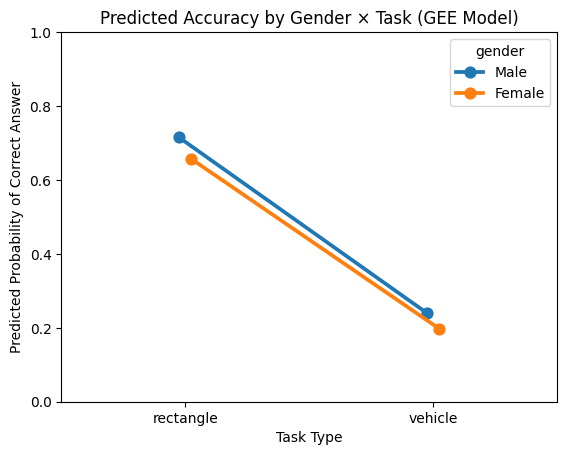

In [50]:


# Create a prediction grid
pred_df = long.copy()
pred_df['predicted'] = result_gee.predict(pred_df)

# Average predictions by gender × task
plot_df = pred_df.groupby(['gender_bin', 'task'], observed=False)['predicted'].mean().reset_index()

# Convert gender to labels
plot_df['gender'] = plot_df['gender_bin'].map({0: 'Male', 1: 'Female'})

sns.pointplot(data=plot_df, x='task', y='predicted', hue='gender', dodge=True, markers='o', capsize=.1)
plt.ylabel("Predicted Probability of Correct Answer")
plt.xlabel("Task Type")
plt.title("Predicted Accuracy by Gender × Task (GEE Model)")
plt.ylim(0, 1)
plt.show()


/tmp/ipython-input-2937383275.py:8: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(data=or_df, y='predictor', x='OR', join=False)


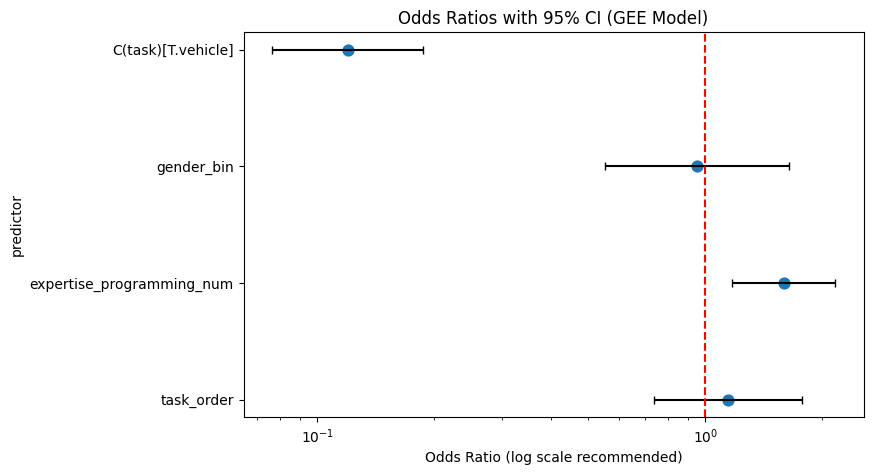

In [51]:
# Prepare OR table
or_df = summary_or.reset_index().rename(columns={'index':'predictor'})

# Remove intercept for clarity
or_df = or_df[or_df['predictor'] != 'Intercept']

plt.figure(figsize=(8,5))
sns.pointplot(data=or_df, y='predictor', x='OR', join=False)
plt.errorbar(or_df['OR'], or_df['predictor'],
             xerr=[or_df['OR'] - or_df['CI_lower'], or_df['CI_upper'] - or_df['OR']],
             fmt='none', c='black', capsize=3)

plt.axvline(1, color='red', linestyle='--')
plt.xlabel("Odds Ratio (log scale recommended)")
plt.title("Odds Ratios with 95% CI (GEE Model)")
plt.xscale('log')
plt.show()


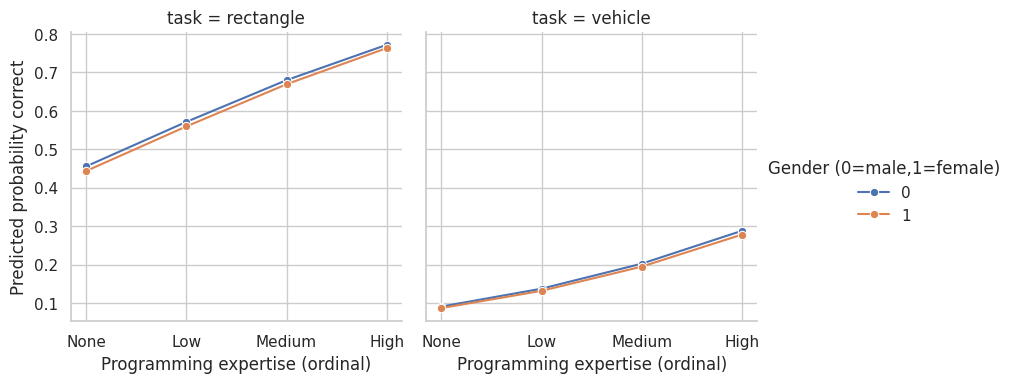

In [52]:
# Build prediction grid
expertise_vals = sorted(long['expertise_programming_num'].dropna().unique())
expertise_labels = {
    0: "None",
    1: "Low",
    2: "Medium",
    3: "High"
}

grid = pd.DataFrame([
    {'gender_bin': g, 'expertise_programming_num': e, 'task': t, 'task_order': 0}
    for g in [0,1] for e in expertise_vals for t in ['rectangle','vehicle']
])
grid['expertise_label'] = grid['expertise_programming_num'].map(expertise_labels)


# Predict probabilities
grid['pred_prob'] = result_gee.predict(grid)

# Plot predicted probabilities by expertise and gender for each task (example)
sns.set(style="whitegrid")
g = sns.FacetGrid(grid, col="task", height=4, sharey=True)
g.map_dataframe(sns.lineplot, x='expertise_label', y='pred_prob', hue='gender_bin', marker='o')
g.add_legend(title='Gender (0=male,1=female)')
g.set_axis_labels("Programming expertise (ordinal)", "Predicted probability correct")
plt.show()

By including programming expertise as a covariate, the analysis effectively compares male and female participants who are matched on self‑reported skill, task type, and task order. Under these conditions, gender did not predict comprehension accuracy, whereas expertise did. This pattern directly challenges the “skill gap” explanation, because once differences in expertise are accounted for, no residual gender effect remains. Although more complex models (e.g., GLMMs with random intercepts) could be used to model individual baseline differences, the current GEE analysis already addresses the central question: given equal expertise and task conditions, gender does not influence performance.

# GLMM - Only for experimental purposes



In [53]:
!pip install bambi pymc





   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.6/109.6 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 218.9/218.9 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.4/259.4 kB 20.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 56.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.6/164.6 kB 14.7 MB/s eta 0:00:00


In [54]:
import bambi as bmb

In [ ]:
model = bmb.Model(
    "correct ~ gender_bin + expertise_programming_num + C(task) + task_order + (1|id)",
    long,
    family="bernoulli"
)

results = model.fit(draws=2000, chains=4)
print(results)